<a href="https://colab.research.google.com/github/alyssaiapalucci4/colab-git-assignment2-AI/blob/main/Lesson_7_assignment_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###### Assignment 7: House Price Prediction Using Boston Housing Data
###### Overview: This project builds a regression model using the Boston Housing dataset to predict house prices.

###### Name: Alyssa Iapalucci

#### GitHub Link: https://github.com/alyssaiapalucci4/colab-git-assignment2-AI

In [1]:
# Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Data Collection and Loading

# Load Boston Housing dataset (modern replacement)
boston = fetch_openml(name="boston", version=1, as_frame=True)

df = boston.frame

# Rename target column for clarity
df.rename(columns={"MEDV": "PRICE"}, inplace=True)

# Show dataset shape
print(df.shape)

(506, 14)


In [3]:
# Quick Check of Data

print(df.head())

print(df.info())

print(df.describe())

print("\nTarget variable: PRICE (continuous)")
print("All other variables are numerical features (no categorical columns in this dataset)")

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-nu

Missing Values in Each Column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


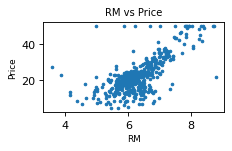

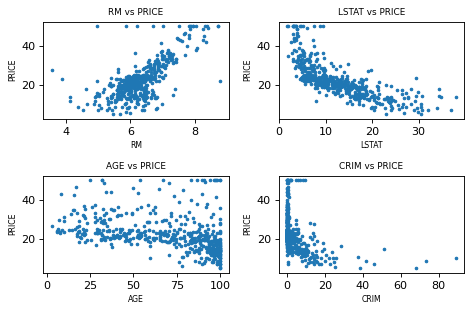

In [11]:
# EDA and Data Preprocessing

import matplotlib.pyplot as plt

# Missing Values Check
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Single Scatter Plot Example
plt.figure(figsize=(3,2), dpi=80)
plt.scatter(df["RM"], df["PRICE"], s=5)
plt.xlabel("RM", fontsize=8)
plt.ylabel("Price", fontsize=8)
plt.title("RM vs Price", fontsize=9)
plt.tight_layout()
plt.show()

# Compact Scatter Plot Function
def plot_features_vs_target(data, features, target):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(6,4),   # much shorter
        dpi=80
    )

    axes = axes.flatten()

    for i, feature in enumerate(features):
        axes[i].scatter(data[feature], data[target], s=5)
        axes[i].set_xlabel(feature, fontsize=7)
        axes[i].set_ylabel(target, fontsize=7)
        axes[i].set_title(f"{feature} vs {target}", fontsize=8)

    plt.tight_layout()
    plt.show()

# Use Function
features_to_plot = ["RM", "LSTAT", "AGE", "CRIM"]
plot_features_vs_target(df, features_to_plot, "PRICE")

In [5]:
# ML Model Training

X = df.drop(columns=["PRICE"])
y = df["PRICE"]

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model (Random Forest)

model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

# Train Model

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

In [6]:
# Model Evaluation

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

# Simple Parameter Tuning

print("\nInterpretation:")
print("R2 closer to 1 means strong model performance.")
print("Lower RMSE means better prediction accuracy.")

RMSE: 2.974665473976816
R2 Score: 0.8793375399340199

Interpretation:
R2 closer to 1 means strong model performance.
Lower RMSE means better prediction accuracy.


In [7]:
# Model Prediction (FIXED)

new_data = pd.DataFrame([[
    0.2, 12.5, 7.07, 0, 0.5, 6.5, 68, 4.0,
    2, 250, 17, 400, 12
]], columns=X.columns)

prediction = model.predict(new_data)

print("Predicted House Price:", prediction[0])

print("\nInterpretation:")
print("This is the predicted median house price based on input features.")

Predicted House Price: 22.333781680004773

Interpretation:
This is the predicted median house price based on input features.
